
# Colab Demo: Time‑Series Foundation Models (Chronos‑Bolt)

This notebook shows how to run **foundation models for forecasting** in Google Colab:
- **Chronos‑Bolt** (Amazon): probabilistic forecasts (quantiles), fast zero‑shot, [Github link](https://github.com/amazon-science/chronos-forecasting).

## 1) Setup

In [ ]:
%%capture
!pip -q install chronos-forecasting pandas matplotlib torch pydantic==2.11.0 --upgrade

## 2) Imports and utilities

In [ ]:
import os, math, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from typing import Sequence

# Metrics
def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom[denom == 0] = 1.0
    return 200.0 * np.mean(np.abs(y_pred - y_true) / denom)

def mase(y_insample: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray, m: int = 1) -> float:
    y_insample = np.asarray(y_insample, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_insample) <= m:
        m = 1
    denom = np.mean(np.abs(y_insample[m:] - y_insample[:-m]))
    if denom == 0:
        denom = 1.0
    return np.mean(np.abs(y_true - y_pred)) / denom

def plot_forecast(history: Sequence[float], median: Sequence[float], lower: Sequence[float] = None, upper: Sequence[float] = None, title: str = ""):
    plt.figure(figsize=(8, 4))
    hist = np.asarray(history, dtype=float)
    plt.plot(range(len(hist)), hist, label="history")
    start = len(hist)
    idx = np.arange(start, start + len(median))
    plt.plot(idx, np.asarray(median, dtype=float), label="forecast")
    if lower is not None and upper is not None:
        plt.fill_between(idx, np.asarray(lower, dtype=float), np.asarray(upper, dtype=float), alpha=0.25, label="interval")
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

## 3) Chronos‑Bolt — zero‑shot on a single series (AirPassengers)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

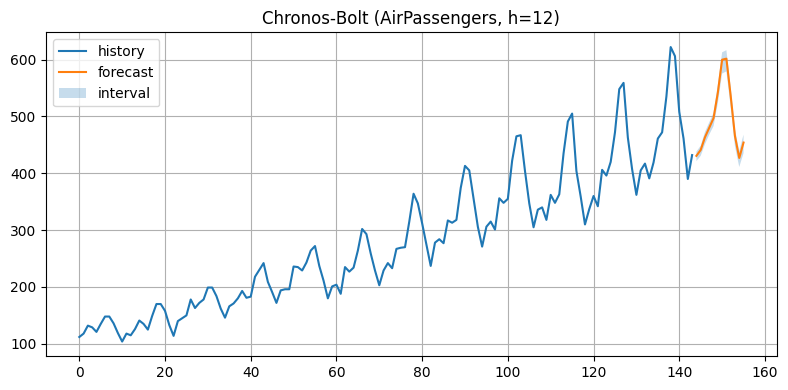

In [ ]:
import pandas as pd
from chronos import BaseChronosPipeline

df = pd.read_csv("https://raw.githubusercontent.com/AileenNielsen/TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv")
y = df["#Passengers"].values.astype(float)

h = 12
pipe = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map=device,
    torch_dtype=torch.bfloat16 if device=="cuda" else torch.float32
)
q = pipe.predict(context=torch.tensor(y), prediction_length=h)
median = q[0,1].tolist()
lower = q[0,0].tolist()
upper = q[0,2].tolist()

plot_forecast(y, median, lower, upper, title="Chronos‑Bolt (AirPassengers, h=12)")
